In [9]:
import pandas as pd
import io

# The raw CSV data is in cell CM8fdJ7GPLgE. We can access its content programmatically.
# Assuming the content of cell CM8fdJ7GPLgE is the CSV string.
csv_data = """
Year,Latitude,Longitude,Avg_Rainfall_mm,Max_Rainfall_mm,River_Discharge_m3s,Water_Level_m,Elevation_m,Population_Density,Flood_Area_km2,Impact_Zone
2005,26.2,91.7,182,295,4120,8.9,54,720,1840,Danger
2006,25.9,92.1,140,210,2850,6.4,88,540,960,Moderate
2007,24.8,86.3,98,165,1940,5.1,140,430,420,Low
2008,26.5,90.4,210,320,4550,9.4,42,980,2360,Danger
2009,23.9,88.1,115,190,2300,6.0,120,610,680,Moderate
2010,25.1,85.2,160,240,3100,7.2,75,790,1320,Danger
2011,24.3,87.6,90,140,1700,4.8,190,390,260,Low
2012,26.0,92.5,225,340,4800,9.9,38,1100,2740,Danger
2013,30.3,79.1,155,260,2980,7.6,610,460,880,Moderate
2014,22.6,88.4,130,205,2450,6.3,92,860,740,Moderate
2015,26.4,90.9,240,360,5200,10.2,36,1200,3180,Danger
2016,25.7,91.3,175,280,3400,8.1,62,880,1560,Danger
2017,24.1,87.9,105,170,2100,5.6,150,520,460,Low
2018,26.8,92.7,260,390,5600,10.8,34,1350,3620,Danger
2019,25.3,86.8,145,220,2750,6.9,98,690,920,Moderate
2020,24.9,88.9,170,265,3300,7.8,80,740,1240,Danger
"""
df = pd.read_csv(io.StringIO(csv_data))
display(df.head())

,Year,Latitude,Longitude,Avg_Rainfall_mm,Max_Rainfall_mm,River_Discharge_m3s,Water_Level_m,Elevation_m,Population_Density,Flood_Area_km2,Impact_Zone
0,2005,26.2,91.7,182,295,4120,8.9,54,720,1840,Danger
1,2006,25.9,92.1,140,210,2850,6.4,88,540,960,Moderate
2,2007,24.8,86.3,98,165,1940,5.1,140,430,420,Low
3,2008,26.5,90.4,210,320,4550,9.4,42,980,2360,Danger
4,2009,23.9,88.1,115,190,2300,6.0,120,610,680,Moderate


In [10]:
df.describe()

,Year,Latitude,Longitude,Avg_Rainfall_mm,Max_Rainfall_mm,River_Discharge_m3s,Water_Level_m,Elevation_m,Population_Density,Flood_Area_km2
count,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000,16.000000
mean,2012.500000,25.550000,88.743750,162.500000,253.125000,3321.250000,7.562500,119.312500,766.250000,1448.750000
std,4.760952,1.690365,3.479266,51.106425,73.821293,1200.199289,1.860421,138.368936,283.028267,1026.942874
min,2005.000000,22.600000,79.100000,90.000000,140.000000,1700.000000,4.800000,34.000000,390.000000,260.000000
25%,2008.750000,24.675000,87.400000,126.250000,201.250000,2412.500000,6.225000,51.000000,535.000000,725.000000
50%,2012.500000,25.500000,88.650000,157.500000,250.000000,3040.000000,7.400000,84.000000,730.000000,1100.000000
75%,2016.250000,26.250000,91.400000,189.000000,301.250000,4227.500000,9.025000,125.000000,905.000000,1970.000000
max,2020.000000,30.300000,92.700000,260.000000,390.000000,5600.000000,10.800000,610.000000,1350.000000,3620.000000


# Task
Build a classification model to predict the 'Impact_Zone' based on the provided flood data, evaluate its performance, and provide insights into the factors influencing flood impact.

## Prepare Data for Prediction

### Subtask:
Preprocess the DataFrame by encoding the 'Impact_Zone' into numerical labels and separating features (X) from the target variable (y). Then, split the data into training and testing sets.


**Reasoning**:
To preprocess the DataFrame, I will first import the necessary libraries, then encode the 'Impact_Zone' column, define the features (X) and target (y), and finally split the data into training and testing sets.



In [11]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

# Initialize LabelEncoder
le = LabelEncoder()

# Encode the 'Impact_Zone' column
df['Impact_Zone_Encoded'] = le.fit_transform(df['Impact_Zone'])

# Define features (X) and target variable (y)
X = df.drop(['Impact_Zone', 'Impact_Zone_Encoded'], axis=1)
y = df['Impact_Zone_Encoded']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Original 'Impact_Zone' categories:", le.classes_)
print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Original 'Impact_Zone' categories: ['Danger' 'Low' 'Moderate']
Shape of X_train: (12, 10)
Shape of X_test: (4, 10)
Shape of y_train: (12,)
Shape of y_test: (4,)


In [12]:
from sklearn.ensemble import RandomForestClassifier

# Instantiate a RandomForestClassifier
model = RandomForestClassifier(random_state=42)

# Train the model
model.fit(X_train, y_train)

print("RandomForestClassifier model trained successfully.")

RandomForestClassifier model trained successfully.


In [13]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Make predictions on the test data
y_pred = model.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Calculate precision
precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)

# Calculate recall
recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)

# Calculate F1-score
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

# Print the evaluation metrics
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Accuracy: 0.7500
Precision: 0.8333
Recall: 0.7500
F1-Score: 0.7333


In [14]:
import pandas as pd

# Convert numerical predictions and actual values back to original labels
actual_labels = le.inverse_transform(y_test)
predicted_labels = le.inverse_transform(y_pred)

# Create a DataFrame to display actual vs. predicted labels
predictions_df = pd.DataFrame({
    'Actual Impact Zone': actual_labels,
    'Predicted Impact Zone': predicted_labels
})

# Display the DataFrame
print("Sample of Actual vs. Predicted Impact Zones:")
display(predictions_df)

Sample of Actual vs. Predicted Impact Zones:


,Actual Impact Zone,Predicted Impact Zone
0,Danger,Danger
1,Moderate,Moderate
2,Danger,Moderate
3,Moderate,Moderate


In [16]:
import pandas as pd

# --- User Input Section ---
# Modify these values to make a new prediction
new_data = {
    'Year': [2021], # While 'Year' was dropped from training features, it's included here for context if the user wants to input it.
    'Latitude': [26.0],
    'Longitude': [91.0],
    'Avg_Rainfall_mm': [150],
    'Max_Rainfall_mm': [230],
    'River_Discharge_m3s': [3000],
    'Water_Level_m': [7.0],
    'Elevation_m': [70],
    'Population_Density': [700],
    'Flood_Area_km2': [1000]
}
new_df = pd.DataFrame(new_data)
expected_features = X_train.columns
new_data_for_prediction = new_df[expected_features]
new_prediction_encoded = model.predict(new_data_for_prediction)
new_prediction_label = le.inverse_transform(new_prediction_encoded)
print(f"Predicted Impact Zone for the given input: {new_prediction_label[0]}")

Predicted Impact Zone for the given input: Moderate


### Visualizing Feature Distributions Across Impact Zones

/tmp/ipython-input-2581127987.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Impact_Zone', y=feature, data=df, order=['Low', 'Moderate', 'Danger'], palette='viridis')
/tmp/ipython-input-2581127987.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Impact_Zone', y=feature, data=df, order=['Low', 'Moderate', 'Danger'], palette='viridis')
/tmp/ipython-input-2581127987.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Impact_Zone', y=feature, data=df, order=['Low', 'Moderate', 'Danger'], palette='viridis')
/tmp/ipython-input-

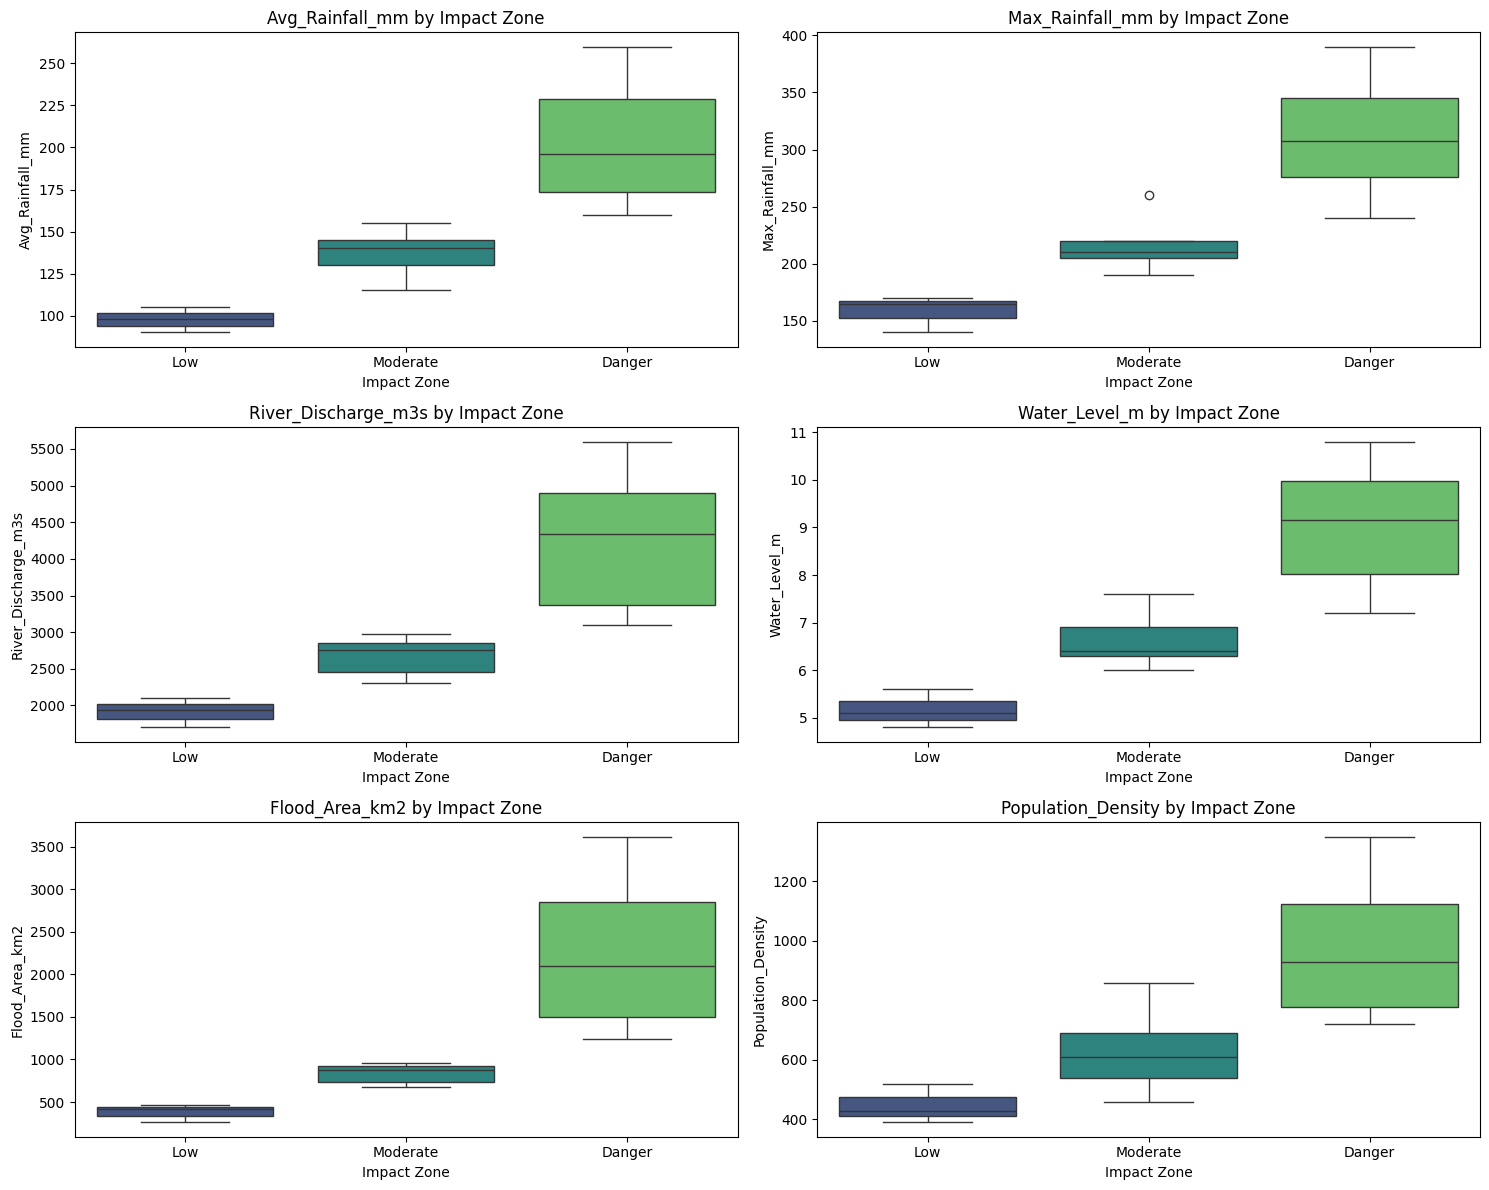

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Features to visualize against Impact_Zone
features_to_plot = ['Avg_Rainfall_mm', 'Max_Rainfall_mm', 'River_Discharge_m3s', 'Water_Level_m', 'Flood_Area_km2', 'Population_Density']

plt.figure(figsize=(15, 12))

for i, feature in enumerate(features_to_plot):
    plt.subplot(3, 2, i + 1) # 3 rows, 2 columns
    sns.boxplot(x='Impact_Zone', y=feature, data=df, order=['Low', 'Moderate', 'Danger'], palette='viridis')
    plt.title(f'{feature} by Impact Zone')
    plt.xlabel('Impact Zone')
    plt.ylabel(feature)

plt.tight_layout()
plt.show()


In [19]:
print("All Actual vs. Predicted Impact Zones from Test Set:")
display(predictions_df)

All Actual vs. Predicted Impact Zones from Test Set:


,Actual Impact Zone,Predicted Impact Zone
0,Danger,Danger
1,Moderate,Moderate
2,Danger,Moderate
3,Moderate,Moderate


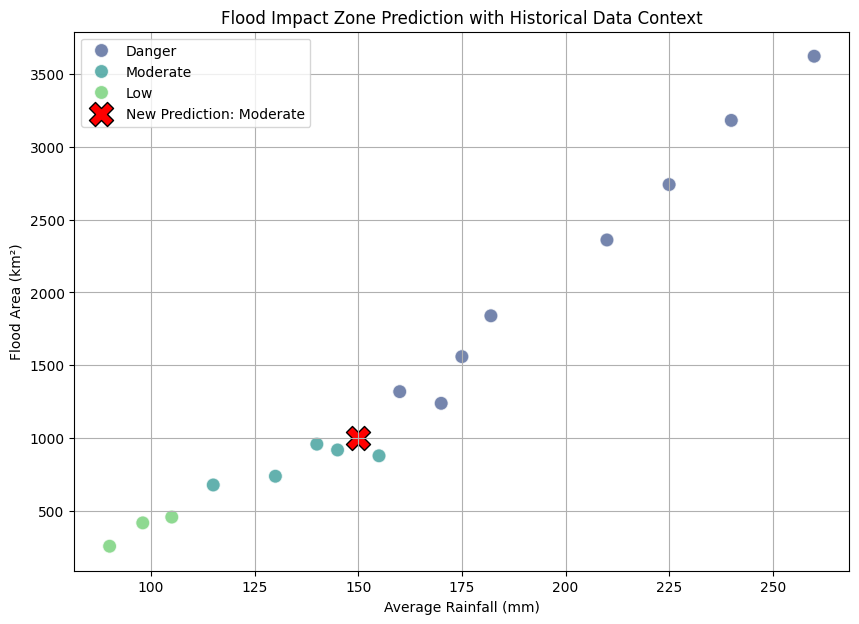

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=df,
    x='Avg_Rainfall_mm',
    y='Flood_Area_km2',
    hue='Impact_Zone',
    palette='viridis',
    s=100, # size of the points
    alpha=0.7,
    legend='full'
)

# Plot the new prediction point
plt.scatter(
    new_data_for_prediction['Avg_Rainfall_mm'],
    new_data_for_prediction['Flood_Area_km2'],
    color='red',
    marker='X',
    s=300, # larger size for emphasis
    label=f'New Prediction: {new_prediction_label[0]}',
    edgecolors='black'
)

plt.title('Flood Impact Zone Prediction with Historical Data Context')
plt.xlabel('Average Rainfall (mm)')
plt.ylabel('Flood Area (km²)')
plt.grid(True)
plt.legend()
plt.show()

In [17]:
import pandas as pd

# Convert numerical predictions and actual values back to original labels
actual_labels = le.inverse_transform(y_test)
predicted_labels = le.inverse_transform(y_pred)

# Create a DataFrame to display actual vs. predicted labels
predictions_df = pd.DataFrame({
    'Actual Impact Zone': actual_labels,
    'Predicted Impact Zone': predicted_labels
})

# Display the DataFrame
print("Sample of Actual vs. Predicted Impact Zones:")
display(predictions_df)

Sample of Actual vs. Predicted Impact Zones:


,Actual Impact Zone,Predicted Impact Zone
0,Danger,Danger
1,Moderate,Moderate
2,Danger,Moderate
3,Moderate,Moderate
